# Data Exploration and Analysis
## Supervised Machine Learning Assignment

**Author:** Boateng Prince Agyenim
**Course:** Data Science & Machine Learning
**Date:** July 29, 2026

---

This notebook explores both datasets:
1. **Housing Dataset** - For price prediction (Regression)
2. **Customer Churn Dataset** - For churn prediction (Classification)

## Setup: Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---
## Part 1: Housing Dataset Exploration

### 1.1 Load and Inspect Data

In [2]:
# Load housing data
housing_df = pd.read_csv("../data/housing.csv")

print("Dataset Shape:", housing_df.shape)
print("\nColumn Names:", housing_df.columns.tolist())
print("\nFirst 5 rows:")
housing_df.head()

Dataset Shape: (500, 5)

Column Names: ['sqft', 'bedrooms', 'age', 'neighborhood', 'price']

First 5 rows:


,sqft,bedrooms,age,neighborhood,price
0,2588.0,3.0,6.0,C,413645.0
1,1850.0,2.0,46.0,B,283644.0
2,2119.0,NaN,73.0,D,404650.0
3,1769.0,1.0,64.0,C,253737.0
4,1706.0,1.0,73.0,A,229356.0


In [3]:
# Dataset info
print("Dataset Information:")
housing_df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sqft          500 non-null    float64
 1   bedrooms      480 non-null    float64
 2   age           500 non-null    float64
 3   neighborhood  485 non-null    object 
 4   price         500 non-null    float64
dtypes: float64(4), object(1)
memory usage: 19.7+ KB


In [4]:
# Statistical summary
print("Statistical Summary:")
housing_df.describe()

Statistical Summary:


,sqft,bedrooms,age,price
count,500.000000,480.000000,500.000000,500.00000
mean,1769.246000,2.929167,41.088000,288245.92400
std,552.646612,1.413912,23.179189,71786.28244
min,450.000000,1.000000,0.000000,96158.00000
25%,1386.750000,2.000000,22.000000,238288.75000
50%,1791.000000,3.000000,41.000000,287535.00000
75%,2110.000000,4.000000,62.000000,336282.25000
max,3548.000000,5.000000,79.000000,489338.00000


### 1.2 Check for Missing Values

In [5]:
# Missing values
missing = housing_df.isnull().sum()
missing_pct = (missing / len(housing_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Analysis:
              Missing Count  Percentage
bedrooms                 20         4.0
neighborhood             15         3.0


### 1.3 Exploratory Data Analysis

In [6]:
# Price statistics
print("Price Statistics:")
print(f"Mean Price: ${housing_df['price'].mean():,.2f}")
print(f"Median Price: ${housing_df['price'].median():,.2f}")
print(f"Min Price: ${housing_df['price'].min():,.2f}")
print(f"Max Price: ${housing_df['price'].max():,.2f}")
print(f"Price Range: ${housing_df['price'].max() - housing_df['price'].min():,.2f}")

Price Statistics:
Mean Price: $288,245.92
Median Price: $287,535.00
Min Price: $96,158.00
Max Price: $489,338.00
Price Range: $393,180.00


In [7]:
# Correlation analysis
print("Correlation with Price:")
corr_with_price = housing_df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(corr_with_price)

Correlation with Price:
price       1.000000
sqft        0.907927
bedrooms    0.075480
age        -0.075336
Name: price, dtype: float64


In [8]:
# Distribution by neighborhood
print("\nAverage Price by Neighborhood:")
avg_price_by_neighborhood = housing_df.groupby('neighborhood')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(avg_price_by_neighborhood)


Average Price by Neighborhood:
                       mean  count
neighborhood                      
D             326200.031250     64
C             293472.084112    107
B             291867.475177    141
A             270288.606936    173


### 1.4 Visualizations

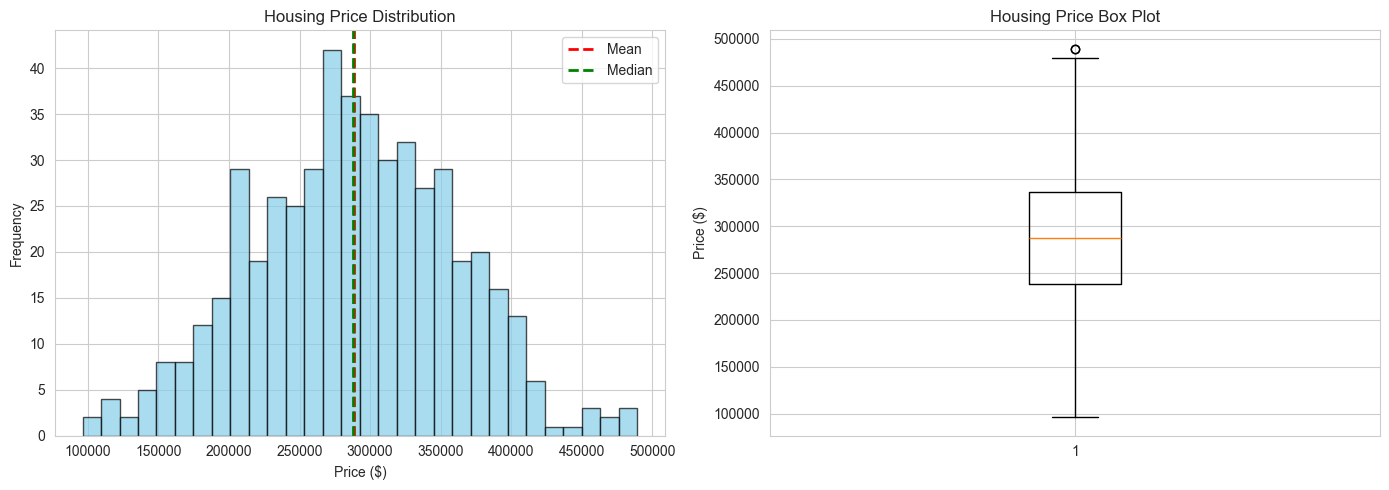

In [9]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(housing_df['price'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(housing_df['price'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(housing_df['price'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Housing Price Distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(housing_df['price'])
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Housing Price Box Plot')

plt.tight_layout()
plt.show()

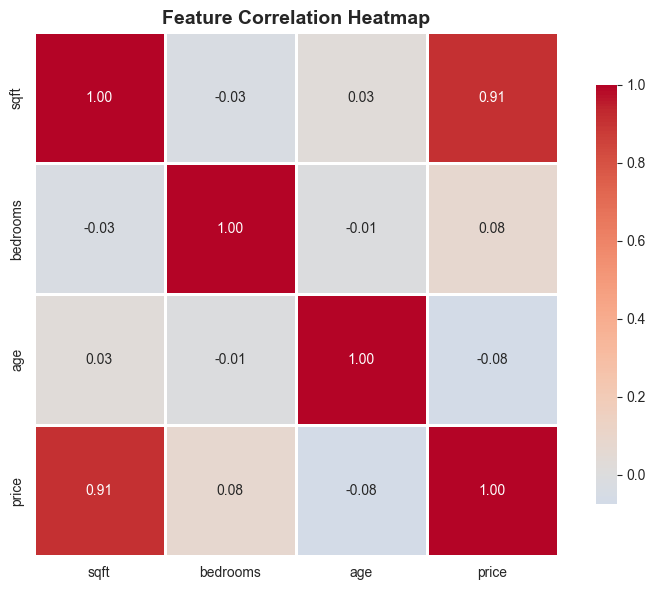

In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = housing_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

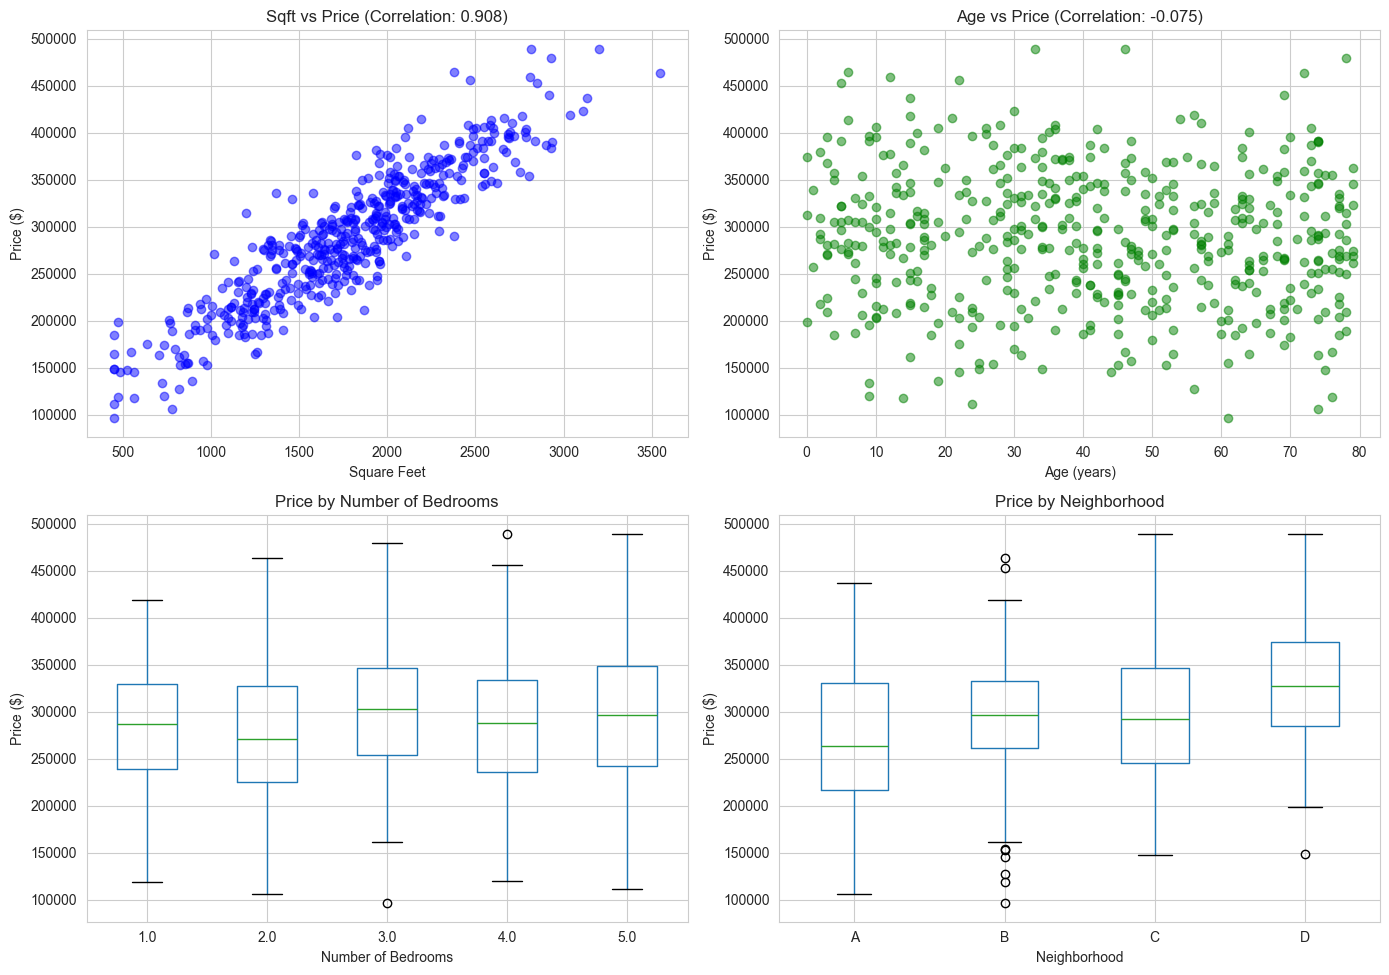

In [11]:
# Feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sqft vs Price
axes[0, 0].scatter(housing_df['sqft'], housing_df['price'], alpha=0.5, color='blue')
axes[0, 0].set_xlabel('Square Feet')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].set_title(f'Sqft vs Price (Correlation: {housing_df["sqft"].corr(housing_df["price"]):.3f})')

# Age vs Price
axes[0, 1].scatter(housing_df['age'], housing_df['price'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_title(f'Age vs Price (Correlation: {housing_df["age"].corr(housing_df["price"]):.3f})')

# Bedrooms vs Price
housing_df.boxplot(column='price', by='bedrooms', ax=axes[1, 0])
axes[1, 0].set_xlabel('Number of Bedrooms')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].set_title('Price by Number of Bedrooms')

# Neighborhood vs Price
housing_df.boxplot(column='price', by='neighborhood', ax=axes[1, 1])
axes[1, 1].set_xlabel('Neighborhood')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].set_title('Price by Neighborhood')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

---
## Part 2: Customer Churn Dataset Exploration

### 2.1 Load and Inspect Data

In [12]:
# Load churn data
churn_df = pd.read_csv("../data/customers.csv")

print("Dataset Shape:", churn_df.shape)
print("\nColumn Names:", churn_df.columns.tolist())
print("\nFirst 5 rows:")
churn_df.head()

Dataset Shape: (800, 6)

Column Names: ['age', 'income', 'tenure', 'contract_type', 'payment_method', 'churn']

First 5 rows:


,age,income,tenure,contract_type,payment_method,churn
0,23.0,42444.0,10.0,Month-to-month,Credit card,1
1,66.0,39413.0,23.0,Month-to-month,Credit card,0
2,47.0,25345.0,68.0,One year,Mailed check,0
3,36.0,60233.0,7.0,Month-to-month,Bank transfer,0
4,18.0,48617.0,45.0,Month-to-month,Bank transfer,0


In [13]:
# Dataset info
print("Dataset Information:")
churn_df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             800 non-null    float64
 1   income          775 non-null    float64
 2   tenure          800 non-null    float64
 3   contract_type   782 non-null    object 
 4   payment_method  800 non-null    object 
 5   churn           800 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 37.6+ KB


In [14]:
# Statistical summary
print("Statistical Summary:")
churn_df.describe()

Statistical Summary:


,age,income,tenure,churn
count,800.000000,775.000000,800.000000,800.000000
mean,45.192500,55917.947097,35.158750,0.308750
std,16.626665,17829.265219,20.610302,0.462267
min,18.000000,15000.000000,0.000000,0.000000
25%,32.000000,43071.500000,18.000000,0.000000
50%,45.000000,55198.000000,35.000000,0.000000
75%,60.000000,68684.500000,53.000000,1.000000
max,74.000000,110072.000000,71.000000,1.000000


### 2.2 Target Variable Analysis

In [15]:
# Churn distribution
churn_counts = churn_df['churn'].value_counts()
churn_pct = churn_df['churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"\nStaying Customers (0): {churn_counts[0]} ({churn_pct[0]:.2f}%)")
print(f"Churned Customers (1): {churn_counts[1]} ({churn_pct[1]:.2f}%)")
print(f"\nOverall Churn Rate: {churn_df['churn'].mean()*100:.2f}%")

Churn Distribution:

Staying Customers (0): 553 (69.12%)
Churned Customers (1): 247 (30.88%)

Overall Churn Rate: 30.88%


### 2.3 Feature Analysis by Churn Status

In [16]:
# Numeric features by churn
print("Average Values by Churn Status:")
print("\n" + "="*60)
for col in ['age', 'income', 'tenure']:
    print(f"\n{col.upper()}:")
    print(churn_df.groupby('churn')[col].agg(['mean', 'median', 'std']))

Average Values by Churn Status:


AGE:
            mean  median        std
churn                              
0      45.415913    45.0  16.942162
1      44.692308    44.0  15.919847

INCOME:
               mean   median           std
churn                                     
0      57539.732342  57049.0  17987.175603
1      52236.426160  51978.0  16933.794088

TENURE:
            mean  median        std
churn                              
0      37.538879    37.0  20.347498
1      29.829960    28.0  20.234083


In [17]:
# Churn rate by categorical features
print("\nChurn Rate by Contract Type:")
contract_churn = churn_df.groupby('contract_type')['churn'].agg(['mean', 'count']).sort_values('mean', ascending=False)
contract_churn['churn_rate_pct'] = contract_churn['mean'] * 100
print(contract_churn)

print("\nChurn Rate by Payment Method:")
payment_churn = churn_df.groupby('payment_method')['churn'].agg(['mean', 'count']).sort_values('mean', ascending=False)
payment_churn['churn_rate_pct'] = payment_churn['mean'] * 100
print(payment_churn)


Churn Rate by Contract Type:
                    mean  count  churn_rate_pct
contract_type                                  
Month-to-month  0.423163    449       42.316258
One year        0.216216    185       21.621622
Two year        0.047297    148        4.729730

Churn Rate by Payment Method:
                      mean  count  churn_rate_pct
payment_method                                   
Electronic check  0.360129    311       36.012862
Mailed check      0.310976    164       31.097561
Credit card       0.266187    139       26.618705
Bank transfer     0.252688    186       25.268817


### 2.4 Visualizations

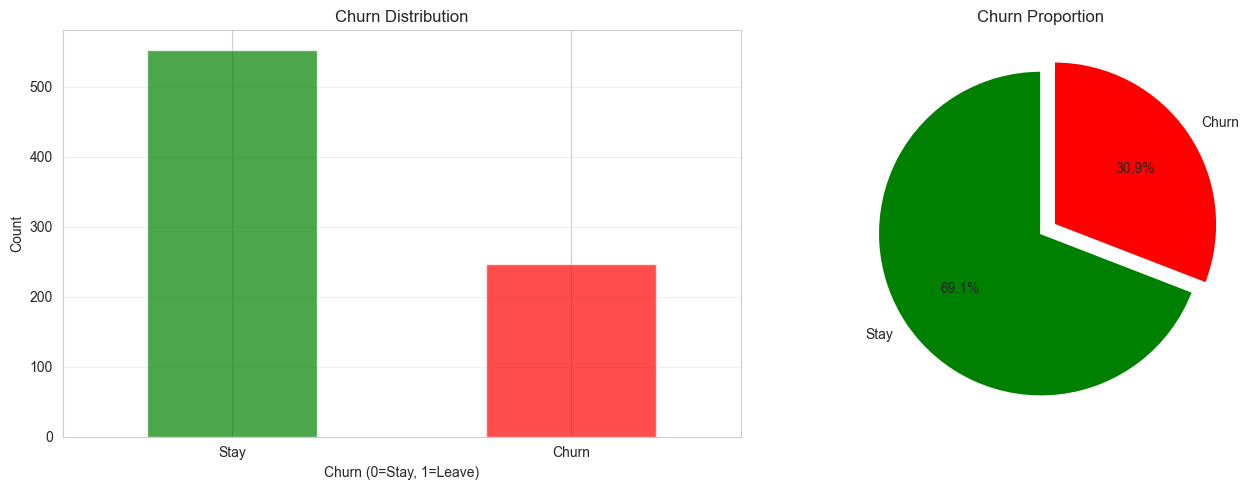

In [18]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7)
axes[0].set_xlabel('Churn (0=Stay, 1=Leave)')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['Stay', 'Churn'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(churn_counts, labels=['Stay', 'Churn'], autopct='%1.1f%%', 
            colors=['green', 'red'], startangle=90, explode=(0, 0.1))
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

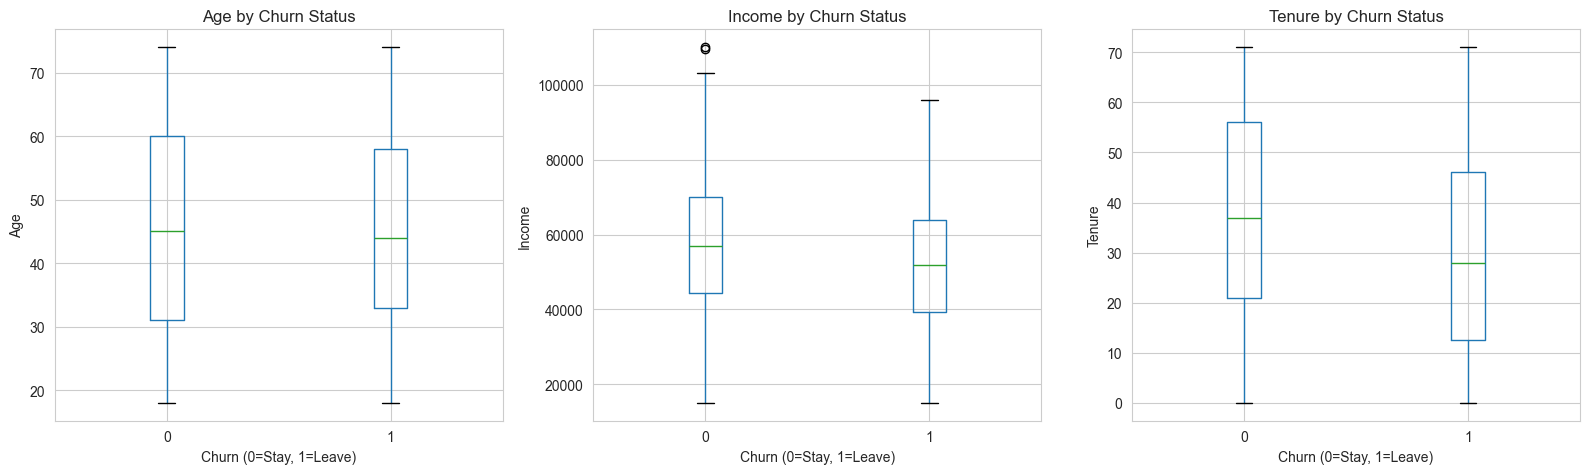

In [19]:
# Numeric features by churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(['age', 'income', 'tenure']):
    churn_df.boxplot(column=col, by='churn', ax=axes[idx])
    axes[idx].set_xlabel('Churn (0=Stay, 1=Leave)')
    axes[idx].set_ylabel(col.capitalize())
    axes[idx].set_title(f'{col.capitalize()} by Churn Status')

plt.suptitle('')
plt.tight_layout()
plt.show()

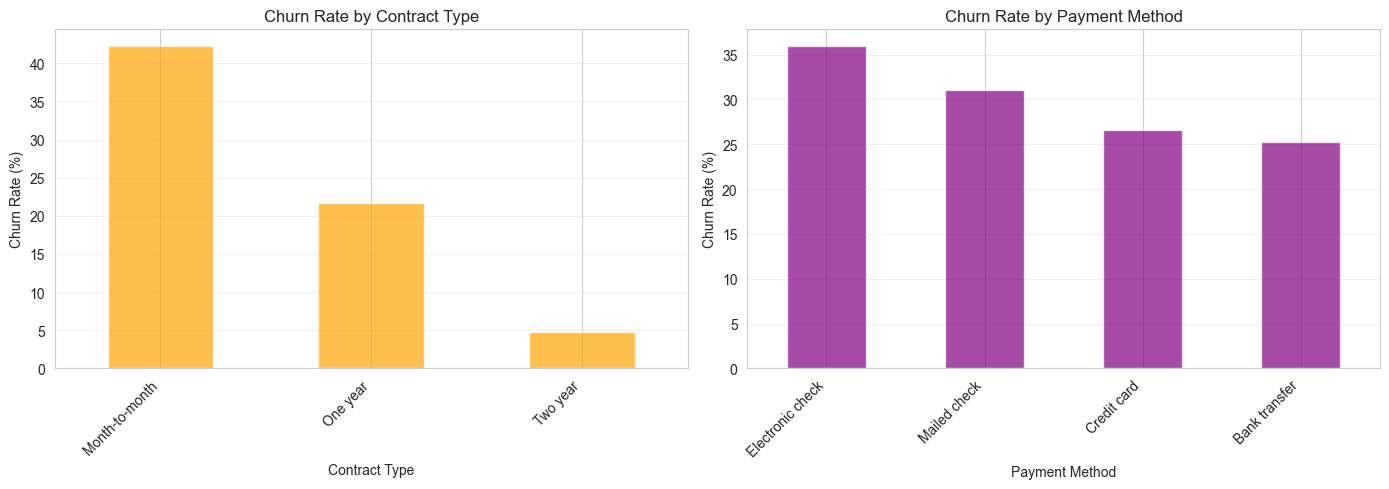

In [20]:
# Categorical features and churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by contract type
contract_churn['churn_rate_pct'].plot(kind='bar', ax=axes[0], color='orange', alpha=0.7)
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Churn by payment method
payment_churn['churn_rate_pct'].plot(kind='bar', ax=axes[1], color='purple', alpha=0.7)
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Key Findings

### Housing Dataset:
1. **Strong Predictor**: Square footage has the highest correlation with price (0.91)
2. **Neighborhood Impact**: Prices vary significantly by neighborhood
3. **Age Effect**: Older houses tend to be slightly cheaper
4. **Missing Data**: 20 bedrooms values and 15 neighborhood values missing

### Churn Dataset:
1. **Class Imbalance**: 69% stay, 31% churn
2. **Contract Type**: Month-to-month contracts have 42% churn vs 5% for two-year
3. **Tenure**: Churned customers have shorter average tenure (30 vs 38 months)
4. **Payment Method**: Electronic check users churn more (36%)
5. **Income**: Churned customers have slightly lower average income

### Implications for Modeling:
- **Housing**: Linear models should work well given strong linear relationships
- **Churn**: Class imbalance requires careful metric selection (F1-score, not just accuracy)
- **Both**: Missing values need imputation before modeling

---
## Next Steps

1. ✅ Data explored and understood
2. → Proceed to preprocessing (Notebook 02)
3. → Train regression models (Notebook 03)
4. → Train classification models (Notebook 04)
5. → Model evaluation and comparison (Notebook 05)